## Bivariate Analysis: Exploring Relationships with Survival

This notebook focuses on **Bivariate Analysis**, where we examine the relationship between two different variables. In this study, our primary variable of interest (the target) is **Survival**.

The goal of this analysis is to determine which factors influenced a passenger's likelihood of survival. By comparing individual features against the survival outcome, we can move beyond simple distributions and begin to uncover the patterns and drivers behind the Titanic tragedy.

---

### Analysis Objectives

We will investigate the survival rate across different demographic and logistical segments:

* **Categorical vs. Categorical:**
    * **Gender & Survival:** Did the "women and children first" policy result in significantly higher survival rates for females?
    * **Class & Survival:** How did socio-economic status (`Pclass`) impact the chance of making it to a lifeboat?
    * **Embarked & Survival:** Did the port of origin have any correlation with survival outcomes?
* **Numerical vs. Categorical:**
    * **Age & Survival:** Were children prioritized, and which age groups were most vulnerable?
    * **Fare & Survival:** Is there a direct correlation between the price paid for a ticket and the survival result?
* **Family Structure & Survival:**
    * How did traveling alone (`alone Traveller`) versus traveling with family (`SibSp`, `Parch`) affect a passenger's outcome?



In [5]:
# imports
from helpers.prepare import *
from helpers.visualization import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [6]:
df=prepare_data('train.csv')
df['alone Traveller'] = (df['SibSp'] == 0) & (df['Parch'] == 0)
df.head()

The Number of Duplicated Rows =  0
The Number of Raws in the data =  891


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,alone Traveller
0,Died,Third Class,male,22.0,1,0,7.2500,S,False
1,Survived,First Class,female,38.0,1,0,71.2833,C,False
2,Survived,Third Class,female,26.0,0,0,7.9250,S,True
3,Survived,First Class,female,35.0,1,0,53.1000,S,False
4,Died,Third Class,male,35.0,0,0,8.0500,S,True


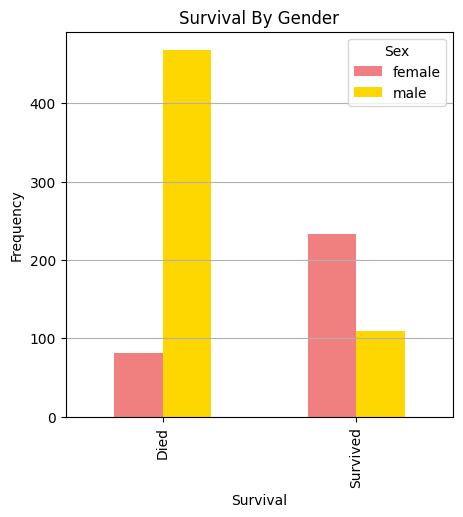

In [18]:
pd.pivot_table(data=df,index='Survived',columns='Sex',values='Fare',aggfunc='count').\
plot(kind='bar',color=['lightcoral', 'gold'],title="Survival By Gender",xlabel='Survival', \
     ylabel='Frequency',figsize=(5,5))
plt.grid(axis='y')
plt.show()

### Survival by Gender

| Gender | Died | Survived | Total | Survival Rate |
| :--- | :--- | :--- | :--- | :--- |
| **Female** | 81 | 233 | 314 | **~74%** |
| **Male** | 468 | 109 | 577 | **~19%** |

**Observation:** There is a stark contrast in survival outcomes between genders. Approximately **3 out of 4 women survived**, whereas only **1 out of 5 men survived**. This strongly validates the historical "women and children first" evacuation protocol and identifies gender as a critical factor in survival probability.

In [20]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,alone Traveller
0,Died,Third Class,male,22.0,1,0,7.2500,S,False
1,Survived,First Class,female,38.0,1,0,71.2833,C,False
2,Survived,Third Class,female,26.0,0,0,7.9250,S,True
3,Survived,First Class,female,35.0,1,0,53.1000,S,False
4,Died,Third Class,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,Died,Second Class,male,27.0,0,0,13.0000,S,True
887,Survived,First Class,female,19.0,0,0,30.0000,S,True
888,Died,Third Class,female,NaN,1,2,23.4500,S,False
889,Survived,First Class,male,26.0,0,0,30.0000,C,True


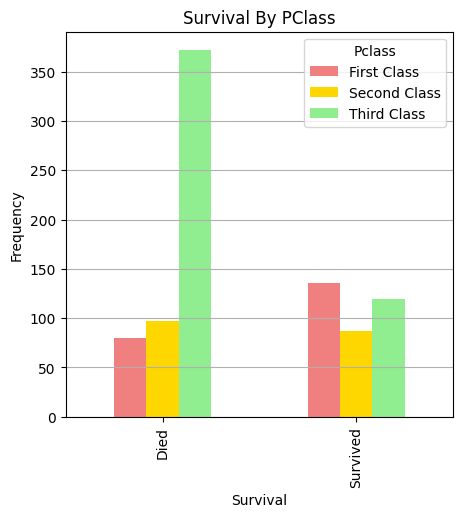

In [27]:
pd.pivot_table(data=df,index='Survived',columns='Pclass',values='Fare',aggfunc='count').\
plot(kind='bar',color=['lightcoral', 'gold','lightgreen'],title="Survival By PClass",xlabel='Survival', \
     ylabel='Frequency',figsize=(5,5))
plt.grid(axis='y')
plt.show()

### Survival by Passenger Class

| Class | Died | Survived | Total | Survival Rate |
| :--- | :--- | :--- | :--- | :--- |
| **First Class** | 80 | 136 | 216 | **~63%** |
| **Second Class** | 97 | 87 | 184 | **~47%** |
| **Third Class** | 372 | 119 | 491 | **~24%** |

**Observation:** Survival rates show a strong positive correlation with socio-economic status. A passenger in **First Class** was more than **2.5 times** as likely to survive as a passenger in **Third Class**. This highlights a clear disparity in access to lifeboats and evacuation priority based on ticket class.

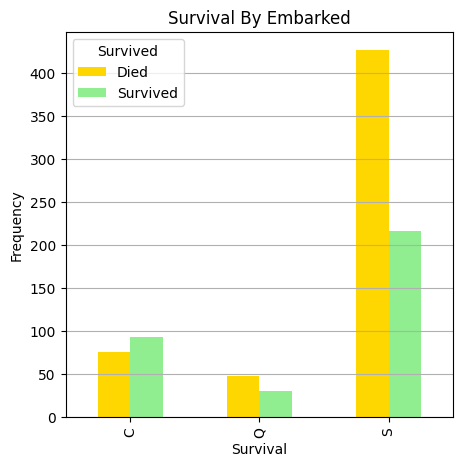

In [28]:
pd.pivot_table(data=df,index='Embarked',columns='Survived',values='Fare',aggfunc='count').\
plot(kind='bar',color=[ 'gold','lightgreen'],title="Survival By Embarked",xlabel='Survival', \
     ylabel='Frequency',figsize=(5,5))
plt.grid(axis='y')
plt.show()

### Survival by Port of Embarkation

| Port | Died | Survived | Total | Survival Rate |
| :--- | :--- | :--- | :--- | :--- |
| **Cherbourg (C)** | 75 | 93 | 168 | **~55%** |
| **Queenstown (Q)** | 47 | 30 | 77 | **~39%** |
| **Southampton (S)** | 427 | 217 | 644 | **~34%** |

**Observation:** Passengers who boarded at **Cherbourg** had the highest survival rate, exceeding 50%. In contrast, those who embarked at **Southampton**—the largest group—experienced the lowest survival rate. This suggests a potential correlation between the port of embarkation and other factors, such as passenger class.

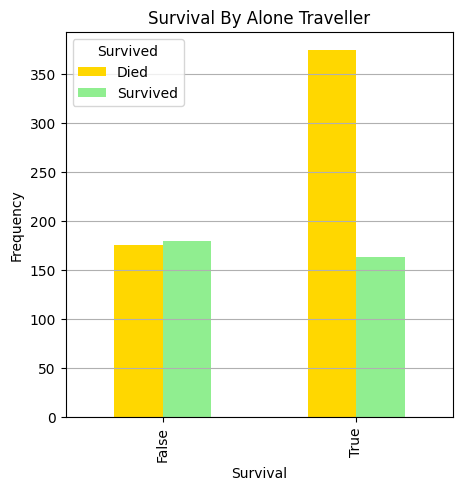

In [32]:
pd.pivot_table(data=df,index='alone Traveller',columns='Survived',values='Fare',aggfunc='count').\
plot(kind='bar',color=[ 'gold','lightgreen'],title="Survival By Alone Traveller",xlabel='Survival', \
     ylabel='Frequency',figsize=(5,5))
plt.grid(axis='y')
plt.show()

In [33]:
pd.pivot_table(data=df,index='alone Traveller',columns='Survived',values='Fare',aggfunc='count')

Survived,Died,Survived
alone Traveller,,
False,175,179
True,374,163


### Survival by Travel Status (`alone Traveller`)

| Traveler Type | Died | Survived | Total | Survival Rate |
| :--- | :--- | :--- | :--- | :--- |
| **With Family** (False) | 175 | 179 | 354 | **~51%** |
| **Alone** (True) | 374 | 163 | 537 | **~30%** |

**Observation:** Traveling with family significantly increased the likelihood of survival. Passengers traveling with at least one family member had a **51% survival rate**, compared to only **30%** for those traveling alone. This suggests that family units may have been prioritized during evacuation or were more successful in reaching lifeboats together.

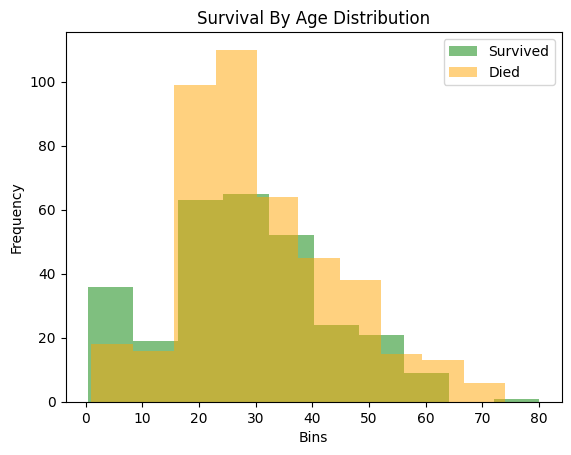

In [49]:
condition=df['Survived']=='Survived'
plt.hist(df[condition]['Age'],bins=10,color='green',alpha=0.5)
condition=df['Survived']!='Survived'
plt.hist(df[condition]['Age'],bins=10,color='orange',alpha=0.5)
plt.legend(['Survived','Died'])
plt.title('Survival By Age Distribution')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.show()

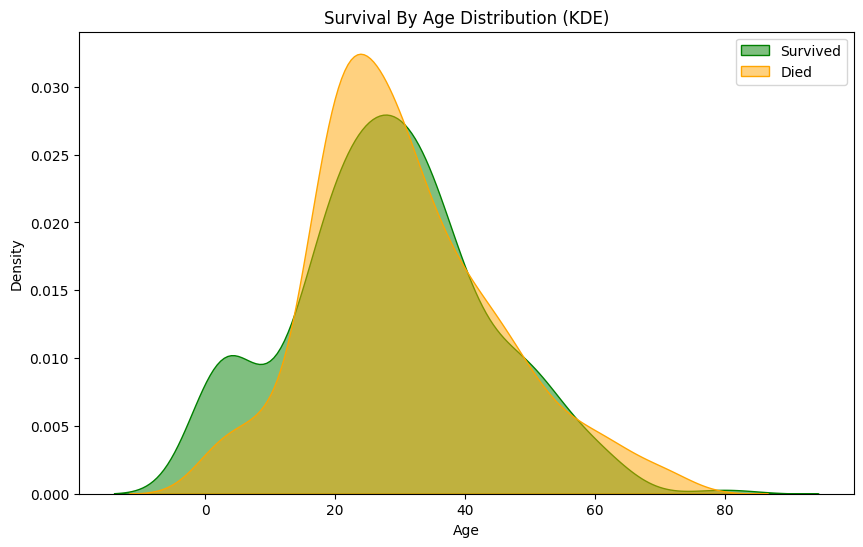

In [50]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['Survived'] == 'Survived']['Age'], fill=True, color='green', label='Survived', alpha=0.5)
sns.kdeplot(data=df[df['Survived'] == 'Died']['Age'], fill=True, color='orange', label='Died', alpha=0.5)

plt.title('Survival By Age Distribution (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

### Survival Analysis: The "Children First" Observation

Based on the distribution shown in the KDE and histogram, the age group between **0 and approximately 16 years** shows a clear survival advantage.

* **Higher Survival Density:** In this lower age bracket, the "Survived" curve (green) sits noticeably higher than the "Died" curve (orange). This indicates that children were significantly more likely to be rescued.


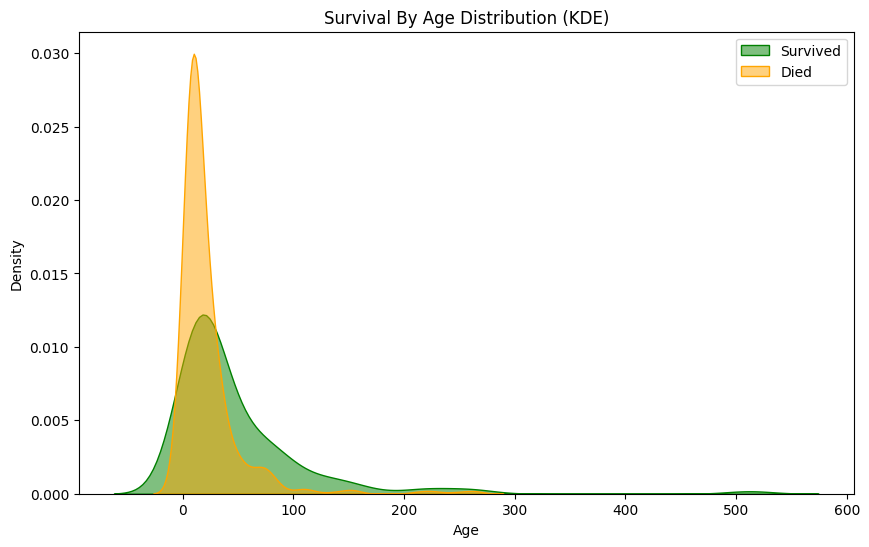

In [52]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['Survived'] == 'Survived']['Fare'], fill=True, color='green', label='Survived', alpha=0.5)
sns.kdeplot(data=df[df['Survived'] == 'Died']['Fare'], fill=True, color='orange', label='Died', alpha=0.5)

plt.title('Survival By Age Distribution (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

### Analysis: The "Wealth Gap" in Survival

* **High Mortality at Low Fares:** There is a massive spike in the "Died" curve at the lowest fare brackets (typically $\$0$–$\$30$). This represents the bulk of the Third Class passengers who faced the greatest barriers to evacuation.
* **Survival Correlation with Cost:** As the fare increases, the density of survivors becomes proportionally higher than the density of those who died. The "Survived" curve has a much "longer tail," extending into the high-fare regions where deaths are almost non-existent.
* **Socio-Economic Safety:** This confirms that survival was not just a matter of gender or age, but was also heavily influenced by financial status. A higher fare essentially bought better access to information, crew assistance, and lifeboats.



**Conclusion:** There is a clear positive correlation between the Fare paid and the likelihood of survival, reinforcing the earlier findings that socio-economic privilege played a decisive role in the disaster's outcome.